In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_ESTIMATORS = 200
MAX_DEPTH = 6

In [3]:
import pandas as pd

# Load Housing dataset
raw_df = pd.read_csv(r"C:\Users\Admin\Downloads\HousingData.csv")

print("Raw data shape:", raw_df.shape)
raw_df.head()

Raw data shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [4]:
processed_df = raw_df.copy()

# Clean column names
processed_df.columns = [c.strip().replace(" ", "_") for c in processed_df.columns]

# Remove duplicate rows
before = processed_df.shape[0]
processed_df = processed_df.drop_duplicates()
print(f"Dropped {before - processed_df.shape[0]} duplicate rows")

# Handle missing values
missing = processed_df.isnull().sum().sum()
print(f"Missing values: {missing}")

if missing > 0:
    processed_df = processed_df.fillna(processed_df.median(numeric_only=True))

# Display summary statistics
processed_df.describe().T

Dropped 0 duplicate rows
Missing values: 120


,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.479140,8.570832,0.00632,0.083235,0.253715,2.808720,88.9762
ZN,506.0,10.768775,23.025124,0.00000,0.000000,0.000000,0.000000,100.0000
INDUS,506.0,11.028893,6.704679,0.46000,5.190000,9.690000,18.100000,27.7400
CHAS,506.0,0.067194,0.250605,0.00000,0.000000,0.000000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.538000,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.208500,6.623500,8.7800
AGE,506.0,68.845850,27.486962,2.90000,45.925000,76.800000,93.575000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.207450,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.000000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.000000,666.000000,711.0000


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = processed_df.drop(columns=["MEDV"])
y = processed_df["MEDV"]

# Split data (NO stratify for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

X_train_scaled.head()

Train shape: (404, 13)
Test shape : (102, 13)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,1.311134,-0.479141,1.085447,-0.272888,0.489252,-1.428069,1.048422,-0.802173,1.706891,1.578434,0.845343,-0.074337,1.791843
15,-0.320131,-0.479141,-0.400912,-0.272888,-0.157233,-0.680087,-0.446698,0.324349,-0.624360,-0.584648,1.204741,0.430184,-0.570585
332,-0.387295,-0.479141,-0.711316,-0.272888,-1.008723,-0.402063,-1.663316,1.330697,-0.974048,-0.602724,-0.637176,0.065297,-0.662553
423,0.407686,-0.479141,1.085447,-0.272888,0.489252,-0.300450,0.297197,-0.839240,1.706891,1.578434,0.845343,-3.868193,1.559049
19,-0.308979,-0.479141,-0.400912,-0.272888,-0.157233,-0.831094,0.029688,-0.005494,-0.624360,-0.584648,1.204741,0.379119,-0.166788


In [7]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE
)

model.fit(X_train_scaled, y_train)

print("Model trained:", model)

Model trained: RandomForestRegressor(max_depth=6, n_estimators=200, random_state=42)


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json
import numpy as np

# Predict house prices
y_pred = model.predict(X_test_scaled)

# Calculate regression metrics
metrics = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "R2_Score": r2_score(y_test, y_pred)
}

# Display metrics
print(json.dumps(metrics, indent=4))

{
    "MAE": 2.1584748507523375,
    "MSE": 9.362256816752703,
    "RMSE": 3.0597805177418693,
    "R2_Score": 0.8723336446957215
}


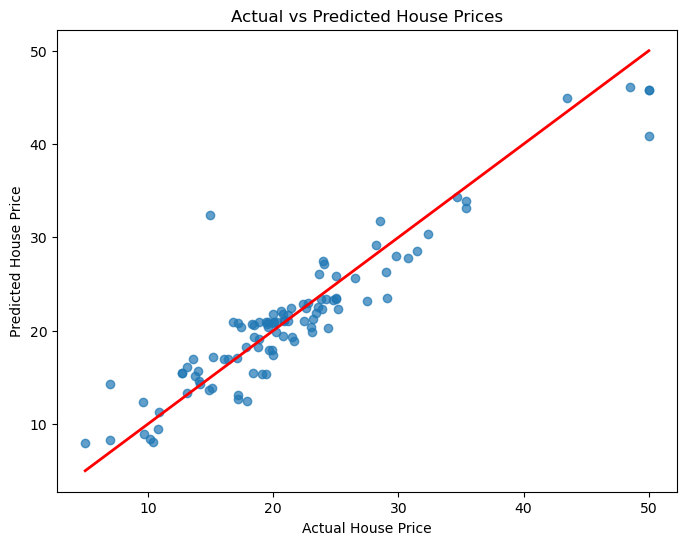

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()